# FLOPS Calculation for Qwen2.5 Models

This notebook calculates the FLOPS (Floating Point Operations) for the Qwen2.5-Instruct model.

| Operation | FLOPS |
| --- | --- |
| Addition/Subtraction/Negation (float OR integer) | 1 |
| Multiplication/Division/Inverse (float OR integer) | 1 |
| ReLU/Absolute Value | 1 |
| Exponentiation/Logarithm | 10 |
| Sine/Cosine/Square Root | 10 |

Table: FLOPS Accounting for Primitives


Matrix multiplication $ m \times n $ by $ n \times p $ (without bias) is $ m \times p \times (2n - 1) $ FLOPS ($ n $ multiplications, $ n-1 $ additions per element). With bias, it’s $ m \times p \times 2n $ (adds $ n $ additions for bias).

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Add the src directory to the path
sys.path.append(os.path.abspath('../'))
from src.utils.flops_calculator import layer_flops, forward_flops, calculate_flops
from qwen import load_qwen

# Set up plotting style
plt.style.use('mystyle.mplstyle')

In [2]:
model, _ = load_qwen()
print(model)
print(model.config)

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2RotaryEmbe

## Overview

The **Qwen2.5 model** is a transformer-based language model comprising the following principal components:

1. **Token Embeddings**: Each input token is mapped to a high-dimensional vector via an embedding lookup. 
   - Conceptually, this corresponds to a matrix multiplication of shape `B × S × V @ V × H`, where `B` is the batch size, `S` the sequence length, `V` the vocabulary size, and `H` the hidden dimension. However, in practice, this operation is implemented as a lookup and incurs **zero FLOPs**.

2. **Positional Encodings**: Positional information is added to the token embeddings to preserve the order of the sequence. (**Rotary Position Embeddings (RoPE)** are used in Qwen2.5 but are omitted here for simplicity.)

3. **Transformer Layers**: The core of the model consists of a stack of identical layers, each comprising the following subcomponents:
   - **RMSNorm**: Root Mean Square Layer Normalization is applied prior to both the self-attention and the feed-forward sublayers.
   - **Self-Attention**: A multi-head attention mechanism enables contextual token interaction. (Qwen2.5 uses **Grouped Query Attention (GQA)**, which is omitted here for simplicity.)
   - **Residual Connection 1**: Adds the input of the attention block to its output.
   - **Feed-Forward Network (FFN)**: A two-layer multilayer perceptron with a SwiGLU activation function.
   - **Residual Connection 2**: Adds the input of the FFN block to its output.

4. **Final Layer Normalization**: A concluding RMSNorm is applied to the output of the last transformer layer to stabilise and scale activations appropriately.

5. **Language Modeling Head**: The final hidden states are projected onto the vocabulary space to produce logits for next-token prediction. This is the only component in which FLOPs are explicitly computed.

---

## 1. Token Embeddings

The model employs **Rotary Position Embeddings (RoPE)** to inject positional information into the attention mechanism. RoPE encodes relative positions by applying a structured rotation to the query and key vectors, thereby enabling the model to capture position-dependent interactions directly within the attention computation.

However, for simplicity, we approximate this step by computing standard positional encodings directly within the embedding layer.



---

## 2. Transformer Layer (×24 Layers)

Each transformer layer in the model comprises the following sequential components:

1. **Input RMSNorm**  
2. **Self-Attention** (approximated as standard multi-head attention)  
3. **Residual Connection (1)**  
4. **Post-Attention RMSNorm**  
5. **Feed-Forward Network (MLP with SwiGLU)**  
6. **Residual Connection (2)**




### Qwen2.5-Instruct-0.5B Model Hyperparameters
- $ B $: Batch size
- $ S $: Sequence length
- $ H = 896 $: Hidden size
- $ I = 4864 $: Intermediate size (MLP)
- $ L = 24 $: Number of layers
- $ N_h = 14 $: Number of attention heads
- $ D_h = 64 $: Head dimension ($ H / N_h = 896 / 14 = 64 $)
- $ V = 151936 $: Vocabulary size

In [3]:
B = 1  # Batch size
S = 1024  # Sequence length

# Parameters for Qwen2.5-0.5B
hidden_size = 896
intermediate_size = 4864
num_heads = 14
head_dim = 64

In [4]:
# Calculate FLOPS for a single transformer layer
single_layer_flops = layer_flops(B, S, hidden_size, intermediate_size, num_heads, head_dim)

# Create a DataFrame for better visualization
components = [
    'Input RMSNorm', 'Query Projection', 'Key Projection', 'Value Projection',
    'Attention Scores', 'Attention Scaling', 'Softmax', 'Weighted Sum',
    'Output Projection', 'Residual Addition 1', 'Post-Attention RMSNorm',
    'Gate Projection', 'Up Projection', 'SwiGLU Activation', 'Element-wise Multiplication',
    'Down Projection', 'Residual Addition 2'
]

values = [
    single_layer_flops['input_layernorm'],
    single_layer_flops['q_proj'],
    single_layer_flops['k_proj'],
    single_layer_flops['v_proj'],
    single_layer_flops['scores'],
    single_layer_flops['scaling'],
    single_layer_flops['softmax'],
    single_layer_flops['weighted_sum'],
    single_layer_flops['o_proj'],
    single_layer_flops['add_residual1'],
    single_layer_flops['post_attention_layernorm'],
    single_layer_flops['gate_proj'],
    single_layer_flops['up_proj'],
    single_layer_flops['activation'],
    single_layer_flops['elementwise_mult'],
    single_layer_flops['down_proj'],
    single_layer_flops['add_residual2']
]

# Calculate percentages
percentages = [v / single_layer_flops['total'] * 100 for v in values]

# Create DataFrame
df_layer = pd.DataFrame({
    'Component': components,
    'FLOPS': values,
    'Percentage': percentages
})

# Add subtotals for attention and MLP
df_layer = pd.concat([df_layer, pd.DataFrame({
    'Component': ['Attention Total', 'MLP Total', 'Layer Total'],
    'FLOPS': [single_layer_flops['attention_total'], single_layer_flops['mlp_total'], single_layer_flops['total']],
    'Percentage': [single_layer_flops['attention_total'] / single_layer_flops['total'] * 100,
                  single_layer_flops['mlp_total'] / single_layer_flops['total'] * 100,
                  100.0]
})])

# Format the numbers for better readability
df_layer['FLOPS_formatted'] = df_layer['FLOPS'].apply(lambda x: f"{x:,}")
df_layer['Percentage'] = df_layer['Percentage'].apply(lambda x: f"{x:.2f}%")

# Display the results
display(df_layer[['Component', 'FLOPS_formatted', 'Percentage']])

,Component,FLOPS_formatted,Percentage
0,Input RMSNorm,"3,681,280",0.01%
1,Query Projection,"1,644,167,168",4.40%
2,Key Projection,"1,644,167,168",4.40%
3,Value Projection,"1,644,167,168",4.40%
4,Attention Scores,"1,864,368,128",4.99%
5,Attention Scaling,"14,680,064",0.04%
6,Softmax,"176,146,432",0.47%
7,Weighted Sum,"1,878,130,688",5.03%
8,Output Projection,"1,643,249,664",4.40%
9,Residual Addition 1,"917,504",0.00%


The majority of FLOPS in a transformer layer come from the linear projections in both the attention mechanism and the feed-forward network.


---

## 3. Complete Model Forward Pass

The total forward-pass FLOP count is obtained by summing the contributions from each component of the model, including token embeddings, all transformer layers (×24), and the output layers (final RMSNorm and LM head).


In [5]:
# Parameters for Qwen2.5-0.5B
num_layers = 24
vocab_size = 151936

# Calculate FLOPS for the forward pass
forward_flops_dict = forward_flops(B, S, hidden_size, intermediate_size, num_layers, num_heads, head_dim, vocab_size)

# Create a DataFrame for better visualization
components = [
    'Initial Embedding',
    'Transformer Layers',
    'Final Layer Norm',
    'Language Modeling Head'
]

values = [
    forward_flops_dict['initial_embedding'],
    forward_flops_dict['layer_flops_total'],
    forward_flops_dict['final_norm'],
    forward_flops_dict['lm_head']
]

# Calculate percentages
total_flops = forward_flops_dict['total']
percentages = [v / total_flops * 100 for v in values]

# Create DataFrame
df_forward = pd.DataFrame({
    'Component': components,
    'FLOPS': values,
    'Percentage': percentages
})

# Add total row
df_forward = pd.concat([df_forward, pd.DataFrame({
    'Component': ['Total Forward Pass'],
    'FLOPS': [total_flops],
    'Percentage': [100.0]
})])

# Format the numbers for better readability
df_forward['FLOPS_formatted'] = df_forward['FLOPS'].apply(lambda x: f"{x:,}")
df_forward['Percentage'] = df_forward['Percentage'].apply(lambda x: f"{x:.2f}%")

# Display the results
display(Markdown(f"### Forward Pass FLOPS for Qwen2.5-0.5B (B={B}, S={S})"))
display(df_forward[['Component', 'FLOPS_formatted', 'Percentage']])

### Forward Pass FLOPS for Qwen2.5-0.5B (B=1, S=1024)

,Component,FLOPS_formatted,Percentage
0,Initial Embedding,"917,504",0.00%
1,Transformer Layers,"896,485,490,688",76.28%
2,Final Layer Norm,"3,681,280",0.00%
3,Language Modeling Head,"278,803,775,488",23.72%
0,Total Forward Pass,"1,175,293,864,960",100.00%


## 4. FLOPS Scaling with Sequence Length


In [6]:
# Sequence lengths to analyze
sequence_lengths = [128, 256, 512, 1024, 2048, 4096, 8192]

# Calculate FLOPS for each sequence length (using 0.5B model, inference only)
seq_flops = {}
for seq_len in sequence_lengths:
    seq_flops[seq_len] = calculate_flops(B=1, S=seq_len, is_training=False, model_size="0.5B")

# Create DataFrame for comparison
df_seq = pd.DataFrame({
    'Sequence Length': sequence_lengths,
    'Total FLOPS': [seq_flops[seq_len]['total_flops'] for seq_len in sequence_lengths],
    'FLOPS per Token': [seq_flops[seq_len]['flops_per_token'] for seq_len in sequence_lengths]
})

# Format for display
df_seq['Total FLOPS'] = df_seq['Total FLOPS'].apply(lambda x: f"{x:,}")
df_seq['FLOPS per Token'] = df_seq['FLOPS per Token'].apply(lambda x: f"{x:,.0f}")

# Display the comparison
display(df_seq)

2025-03-26 02:20:10,818 - src.utils.flops_calculator - INFO - Inference FLOPs: total=136,584,308,096
2025-03-26 02:20:10,818 - src.utils.flops_calculator - INFO - Inference FLOPs: total=276,119,309,056
2025-03-26 02:20:10,819 - src.utils.flops_calculator - INFO - Inference FLOPs: total=564,041,389,568
2025-03-26 02:20:10,820 - src.utils.flops_calculator - INFO - Inference FLOPs: total=1,175,293,864,960
2025-03-26 02:20:10,820 - src.utils.flops_calculator - INFO - Inference FLOPs: total=2,539,432,073,216
2025-03-26 02:20:10,821 - src.utils.flops_calculator - INFO - Inference FLOPs: total=5,834,241,519,616
2025-03-26 02:20:10,821 - src.utils.flops_calculator - INFO - Inference FLOPs: total=14,689,992,531,968


,Sequence Length,Total FLOPS,FLOPS per Token
0,128,"136,584,308,096","1,067,064,907"
1,256,"276,119,309,056","1,078,591,051"
2,512,"564,041,389,568","1,101,643,339"
3,1024,"1,175,293,864,960","1,147,747,915"
4,2048,"2,539,432,073,216","1,239,957,067"
5,4096,"5,834,241,519,616","1,424,375,371"
6,8192,"14,689,992,531,968","1,793,211,979"


### Visualizing FLOPS Scaling with Sequence Length

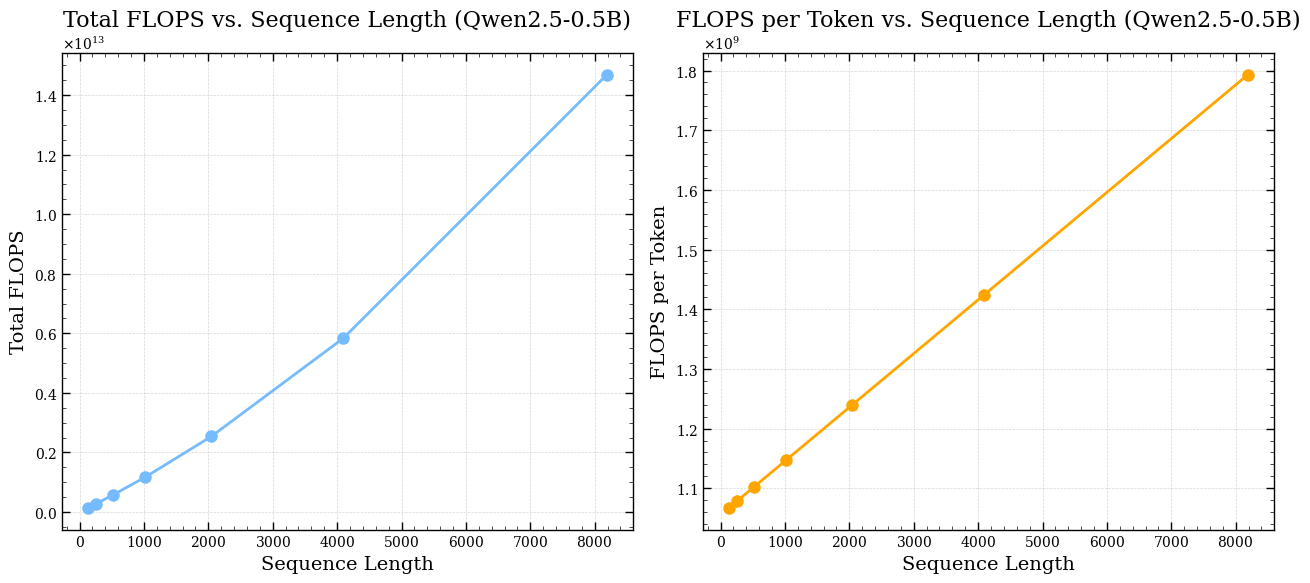

In [7]:
# Extract data for plotting
seq_lens = sequence_lengths
seq_flops_values = [seq_flops[seq_len]['total_flops'] for seq_len in sequence_lengths]
seq_flops_per_token = [seq_flops[seq_len]['flops_per_token'] for seq_len in sequence_lengths]

# Create plot for total FLOPS
plt.figure(figsize=(13, 6))

plt.subplot(1, 2, 1)
plt.plot(seq_lens, seq_flops_values, 'o-', linewidth=2, markersize=8)
plt.grid(True)
plt.xlabel('Sequence Length', fontsize=14)
plt.ylabel('Total FLOPS', fontsize=14)
plt.title('Total FLOPS vs. Sequence Length (Qwen2.5-0.5B)', fontsize=16)

# Create plot for FLOPS per token
plt.subplot(1, 2, 2)
plt.plot(seq_lens, seq_flops_per_token, 'o-', linewidth=2, markersize=8, color='orange')
plt.grid(True)
plt.xlabel('Sequence Length', fontsize=14)
plt.ylabel('FLOPS per Token', fontsize=14)
plt.title('FLOPS per Token vs. Sequence Length (Qwen2.5-0.5B)', fontsize=16)

plt.tight_layout()
plt.show()

Total FLOPS scale linearly with sequence length, but there's a quadratic component in the attention mechanism due to the O(n²) complexity of computing attention scores.

In [8]:
import plotly.graph_objects as go
from plotly.offline import iplot
# Get detailed FLOPS for Qwen2.5-0.5B
detailed_flops = calculate_flops(B=1, S=1024, is_training=False, model_size="0.5B")
# Single layer breakdown
layer_dict = detailed_flops['forward_pass']['layer_flops_per_layer']

# This requires more complex data preparation
# Define the nodes (components)
node_labels = [
    'Total', 
    'Embeddings', 'Transformer Layers', 'Final Norm', 'LM Head',
    'Attention', 'MLP', 'Norm', 'Residual',
    'Q Proj', 'K Proj', 'V Proj', 'Scores', 'Scaling', 'Softmax', 'Weighted Sum', 'O Proj',
    'Gate Proj', 'Up Proj', 'Activation', 'Element-wise', 'Down Proj'
]

# Define the links (flows)
source = [0, 0, 0, 0,  # Total to main components
          2, 2, 2, 2,  # Transformer to sub-components
          5, 5, 5, 5, 5, 5, 5, 5,  # Attention to details
          6, 6, 6, 6, 6]  # MLP to details
          
target = [1, 2, 3, 4,  # From Total
          5, 6, 7, 8,  # From Transformer
          9, 10, 11, 12, 13, 14, 15, 16,  # From Attention
          17, 18, 19, 20, 21]  # From MLP
          
# Values are the FLOPS
layer_total = layer_dict['total'] * num_layers
total_flops = detailed_flops['total_flops']

values = [
    detailed_flops['forward_pass']['initial_embedding'],
    detailed_flops['forward_pass']['layer_flops_total'],
    detailed_flops['forward_pass']['final_norm'],
    detailed_flops['forward_pass']['lm_head'],
    
    layer_dict['attention_total'] * num_layers,
    layer_dict['mlp_total'] * num_layers,
    (layer_dict['input_layernorm'] + layer_dict['post_attention_layernorm']) * num_layers,
    (layer_dict['add_residual1'] + layer_dict['add_residual2']) * num_layers,
    
    layer_dict['q_proj'] * num_layers,
    layer_dict['k_proj'] * num_layers,
    layer_dict['v_proj'] * num_layers,
    layer_dict['scores'] * num_layers,
    layer_dict['scaling'] * num_layers,
    layer_dict['softmax'] * num_layers,
    layer_dict['weighted_sum'] * num_layers,
    layer_dict['o_proj'] * num_layers,
    
    layer_dict['gate_proj'] * num_layers,
    layer_dict['up_proj'] * num_layers,
    layer_dict['activation'] * num_layers,
    layer_dict['elementwise_mult'] * num_layers,
    layer_dict['down_proj'] * num_layers
]

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels
    ),
    link=dict(
        source=source,
        target=target,
        value=values
    )
)])

fig.update_layout(
    title_text="FLOPS Flow in Qwen2.5-0.5B Model",
    font_size=14,
    width=1000, 
    height=800
)

fig.show()

2025-03-26 02:20:11,287 - src.utils.flops_calculator - INFO - Inference FLOPs: total=1,175,293,864,960
